<a href="https://colab.research.google.com/github/sungfeliks/Lightweight-Mixture-of-Experts-with-Knowledge-Distillation-Vision-Language-Model/blob/main/01_CBIS_DDSM_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Add Kaggle.json**

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"felikssung","key":"0e984d959930980226e0f8c1fb479c3e"}'}

In [2]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# **Download the CBIS-DDSM directly from Kaggle**

In [3]:
!kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset

import zipfile
with zipfile.ZipFile('cbis-ddsm-breast-cancer-image-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('cbis_ddsm_awsaf')

Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
100% 4.95G/4.95G [00:39<00:00, 134MB/s]



# **Import all the necessary libraries**

In [4]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

# **Dataset Preparation**

**Dataset Path**

In [5]:
DATASET_DIR = "cbis_ddsm_awsaf"

CSV_DIR = os.path.join(DATASET_DIR, "csv")
JPEG_DIR = os.path.join(DATASET_DIR, "jpeg")

**Load dicom_info**

In [6]:
dicom_info = pd.read_csv(
    os.path.join(CSV_DIR, "dicom_info.csv")
)

dicom_info["image_path"] = dicom_info["image_path"].apply(
    lambda x: x.replace("CBIS-DDSM", DATASET_DIR)
)

dicom_info.head()

,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN


**Separate all image types**

In [7]:
full_images = dicom_info[
    dicom_info.SeriesDescription == "full mammogram images"
].image_path

cropped_images = dicom_info[
    dicom_info.SeriesDescription == "cropped images"
].image_path

roi_images = dicom_info[
    dicom_info.SeriesDescription == "ROI mask images"
].image_path

**Fix JPEG Path**

In [8]:
full_images = full_images.apply(
    lambda x: x.replace("CBIS-DDSM/jpeg", JPEG_DIR)
)

cropped_images = cropped_images.apply(
    lambda x: x.replace("CBIS-DDSM/jpeg", JPEG_DIR)
)

roi_images = roi_images.apply(
    lambda x: x.replace("CBIS-DDSM/jpeg", JPEG_DIR)
)

**Build Mapping Dictionary**

In [9]:
def build_dict(paths):

    mapping = {}

    for p in paths:

        uid = os.path.basename(
            os.path.dirname(p)
        )

        mapping[uid] = p

    return mapping


full_dict = build_dict(full_images)

crop_dict = build_dict(cropped_images)

roi_dict = build_dict(roi_images)

**Load Metadata**

In [10]:
mass_train = pd.read_csv(
    os.path.join(CSV_DIR,
    "mass_case_description_train_set.csv")
)

mass_test = pd.read_csv(
    os.path.join(CSV_DIR,
    "mass_case_description_test_set.csv")
)

calc_train = pd.read_csv(
    os.path.join(CSV_DIR,
    "calc_case_description_train_set.csv")
)

calc_test = pd.read_csv(
    os.path.join(CSV_DIR,
    "calc_case_description_test_set.csv")
)

**Add Case Type**

In [11]:
mass_train["case_type"] = "Mass"
mass_test["case_type"] = "Mass"

calc_train["case_type"] = "Calcification"
calc_test["case_type"] = "Calcification"

**Function Fix Path**

In [12]:
def replace_path(old_path, mapping):

    if pd.isna(old_path):
        return np.nan

    try:

        uid = old_path.split("/")[2]

        return mapping.get(uid, np.nan)

    except:

        return np.nan

**Update all datasets**

In [13]:
datasets = [
    mass_train,
    mass_test,
    calc_train,
    calc_test
]

for df in datasets:

    df["image file path"] = df[
        "image file path"
    ].apply(
        lambda x: replace_path(x, full_dict)
    )

    df["cropped image file path"] = df[
        "cropped image file path"
    ].apply(
        lambda x: replace_path(x, crop_dict)
    )

    df["ROI mask file path"] = df[
        "ROI mask file path"
    ].apply(
        lambda x: replace_path(x, roi_dict)
    )

# Pre-**processing**

**Rename Column**

In [14]:
def clean_columns(df):

    df.columns = (
        df.columns
        .str.lower()
        .str.replace(" ", "_")
    )

    return df

In [15]:
mass_train = clean_columns(mass_train)
mass_test = clean_columns(mass_test)

calc_train = clean_columns(calc_train)
calc_test = clean_columns(calc_test)

**Missing Values (Mass)**

In [16]:
mass_train["mass_shape"] = mass_train["mass_shape"].fillna("UNKNOWN")
mass_train["mass_margins"] = mass_train["mass_margins"].fillna("UNKNOWN")

mass_test["mass_shape"] = mass_test["mass_shape"].fillna("UNKNOWN")
mass_test["mass_margins"] = mass_test["mass_margins"].fillna("UNKNOWN")

**Missing Value (Calcification)**

In [17]:
calc_train["calc_type"] = calc_train["calc_type"].fillna("UNKNOWN")
calc_train["calc_distribution"] = calc_train["calc_distribution"].fillna("UNKNOWN")

calc_test["calc_type"] = calc_test["calc_type"].fillna("UNKNOWN")
calc_test["calc_distribution"] = calc_test["calc_distribution"].fillna("UNKNOWN")

**Merge**

In [18]:
cbis = pd.concat(
    [
        mass_train,

        mass_test,

        calc_train,

        calc_test
    ],

    ignore_index=True

)

**Binary Label**

In [19]:
def make_label(pathology):

    pathology = pathology.upper()

    if pathology == "MALIGNANT":

        return 1

    else:

        return 0

In [20]:
cbis["label"] = cbis.pathology.apply(
    make_label
)

**Use Full Mammogram**

In [21]:
cbis["img_path"] = cbis[
    "image_file_path"
]

**Add Dataset Column**

In [22]:
cbis["dataset"] = "CBIS-DDSM"

**Remove Invalid Path**

In [23]:
def file_exists(path):
    if not isinstance(path, str):
        return False
    return os.path.exists(path)

cbis = cbis[
    cbis["img_path"].apply(file_exists)
].reset_index(drop=True)

**Quick Check**

In [24]:
print(cbis.shape)

print()

print(cbis["label"].value_counts())

print()

print(cbis["case_type"].value_counts())

(3286, 20)

label
0    1931
1    1355
Name: count, dtype: int64

case_type
Mass             1696
Calcification    1590
Name: count, dtype: int64


**Patient Split**

In [25]:
patients = cbis["patient_id"].unique()

print(
    f"Total Patients: {len(patients)}"
)

Total Patients: 1460


In [26]:
train_patients, temp_patients = train_test_split(

    patients,

    test_size=0.30,

    random_state=42,

    shuffle=True
)

In [27]:
val_patients, test_patients = train_test_split(

    temp_patients,

    test_size=0.50,

    random_state=42,

    shuffle=True
)

**Build Train**

In [28]:
train_df = cbis[
    cbis["patient_id"].isin(train_patients)
].copy()

val_df = cbis[
    cbis["patient_id"].isin(val_patients)
].copy()

test_df = cbis[
    cbis["patient_id"].isin(test_patients)
].copy()

**Verify Leakage**

In [29]:
train_set = set(train_df.patient_id)
val_set = set(val_df.patient_id)
test_set = set(test_df.patient_id)

print(
    "Train-Val:",
    len(train_set & val_set)
)

print(
    "Train-Test:",
    len(train_set & test_set)
)

print(
    "Val-Test:",
    len(val_set & test_set)
)

Train-Val: 0
Train-Test: 0
Val-Test: 0


**Check Distribution**

In [30]:
print(train_df["label"].value_counts())

print(val_df["label"].value_counts())

print(test_df["label"].value_counts())

label
0    1367
1     952
Name: count, dtype: int64
label
0    274
1    206
Name: count, dtype: int64
label
0    290
1    197
Name: count, dtype: int64


**Save the CSV**

In [31]:
SAVE_DIR = "prepared_dataset"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

In [32]:
train_df.to_csv(

    f"{SAVE_DIR}/train.csv",

    index=False

)

val_df.to_csv(

    f"{SAVE_DIR}/val.csv",

    index=False

)

test_df.to_csv(

    f"{SAVE_DIR}/test.csv",

    index=False

)

# **Mammogram Samples**

In [33]:
import matplotlib.pyplot as plt
from PIL import Image

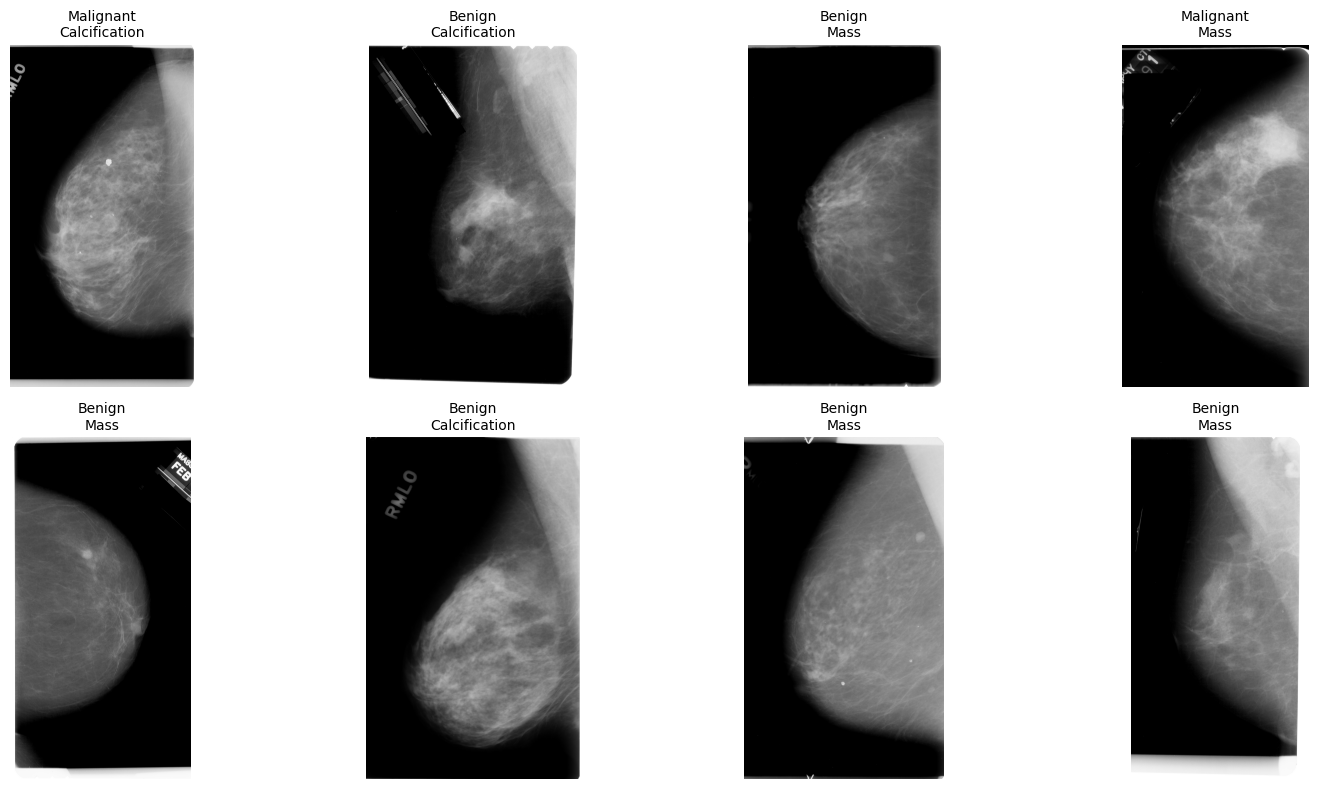

In [34]:
samples = cbis.sample(
    8,
    random_state=42
)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16,8)
)

for ax, (_, row) in zip(
    axes.flatten(),
    samples.iterrows()
):

    img = Image.open(
        row["img_path"]
    )

    ax.imshow(
        img,
        cmap="gray"
    )

    label = (
        "Malignant"
        if row["label"] == 1
        else "Benign"
    )

    ax.set_title(
        f"{label}\n{row['case_type']}",
        fontsize=10
    )

    ax.axis("off")

plt.tight_layout()

plt.show()